In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv("//Users/zofiabrodewicz/Documents/GitHub/Bachelor/collaborations_with_distances.csv")
df["log_avg_streams"] = np.log10(df["avg_streams"])

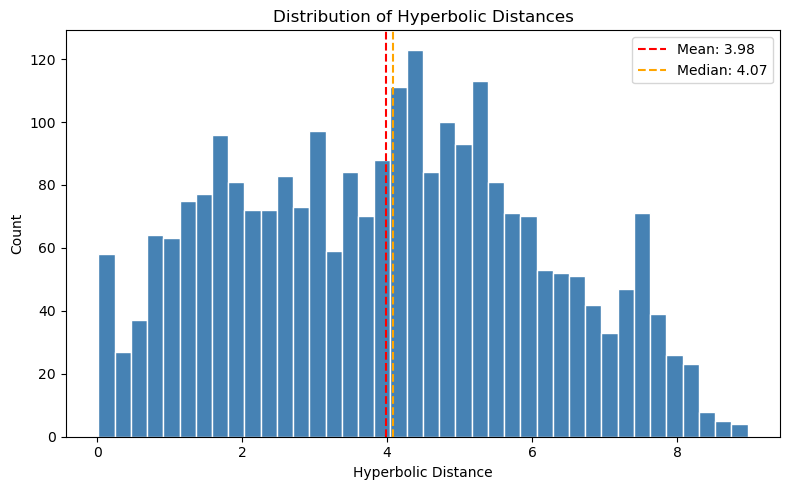

In [17]:
#  Plot 1: Distribution of distances 
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["hyperbolic_distance"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(df["hyperbolic_distance"].mean(), color="red", linestyle="--",
           label=f'Mean: {df["hyperbolic_distance"].mean():.2f}')
ax.axvline(df["hyperbolic_distance"].median(), color="orange", linestyle="--",
           label=f'Median: {df["hyperbolic_distance"].median():.2f}')
ax.set_title("Distribution of Hyperbolic Distances")
ax.set_xlabel("Hyperbolic Distance")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()



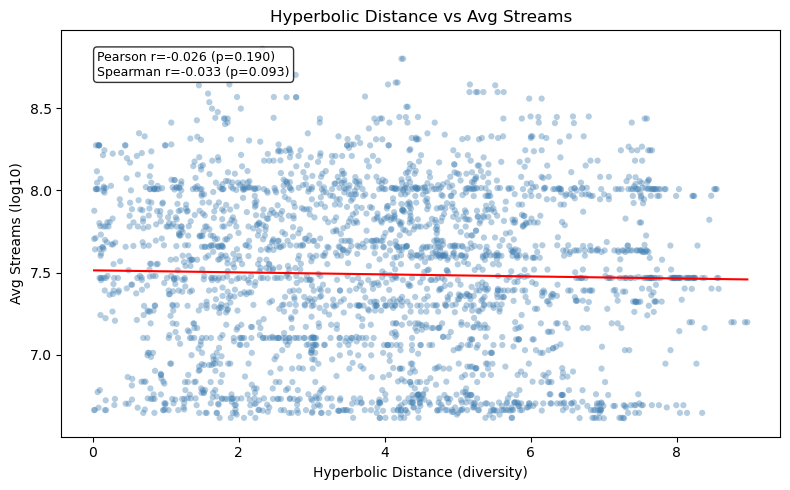

In [21]:
# Plot 2: Distance vs avg_streams 
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["hyperbolic_distance"], df["log_avg_streams"],
           alpha=0.4, color="steelblue", edgecolors="none", s=20)
z = np.polyfit(df["hyperbolic_distance"], df["log_avg_streams"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["hyperbolic_distance"].min(), df["hyperbolic_distance"].max(), 100)
ax.plot(x_line, p(x_line), color="red", linewidth=1.5)
pearson_r, pearson_p = stats.pearsonr(df["hyperbolic_distance"], df["log_avg_streams"])
spearman_r, spearman_p = stats.spearmanr(df["hyperbolic_distance"], df["log_avg_streams"])
ax.set_title("Hyperbolic Distance vs Avg Streams")
ax.set_xlabel("Hyperbolic Distance (diversity)")
ax.set_ylabel("Avg Streams (log10)")
ax.text(0.05, 0.95,
        f"Pearson r={pearson_r:.3f} (p={pearson_p:.3f})\nSpearman r={spearman_r:.3f} (p={spearman_p:.3f})",
        transform=ax.transAxes, fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()


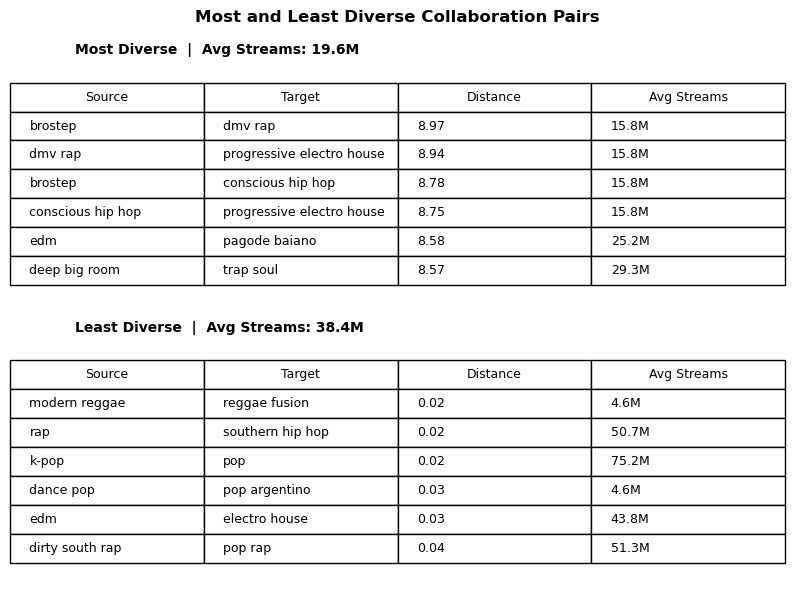

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
fig.suptitle("Most and Least Diverse Collaboration Pairs",
             fontsize=12, fontweight="bold")

top_diverse = df.nlargest(6, "hyperbolic_distance")[["source", "target", "hyperbolic_distance", "avg_streams"]]
top_similar = df.nsmallest(6, "hyperbolic_distance")[["source", "target", "hyperbolic_distance", "avg_streams"]]

# average streams per group
avg_streams_diverse = top_diverse["avg_streams"].mean()
avg_streams_similar = top_similar["avg_streams"].mean()

diverse_data = [[row["source"], row["target"],
                 f'{row["hyperbolic_distance"]:.2f}',
                 f'{row["avg_streams"]/1e6:.1f}M']
                for _, row in top_diverse.iterrows()]
similar_data = [[row["source"], row["target"],
                 f'{row["hyperbolic_distance"]:.2f}',
                 f'{row["avg_streams"]/1e6:.1f}M']
                for _, row in top_similar.iterrows()]

for ax, data, title, avg_streams in zip(
    axes,
    [diverse_data, similar_data],
    ["Most Diverse", "Least Diverse"],
    [avg_streams_diverse, avg_streams_similar]
):
    ax.axis("off")
    ax.set_title(f"{title}  |  Avg Streams: {avg_streams/1e6:.1f}M",
                 fontsize=10, fontweight="bold", loc="left")
    table = ax.table(cellText=data,
                     colLabels=["Source", "Target", "Distance", "Avg Streams"],
                     loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)

plt.tight_layout()
plt.show()

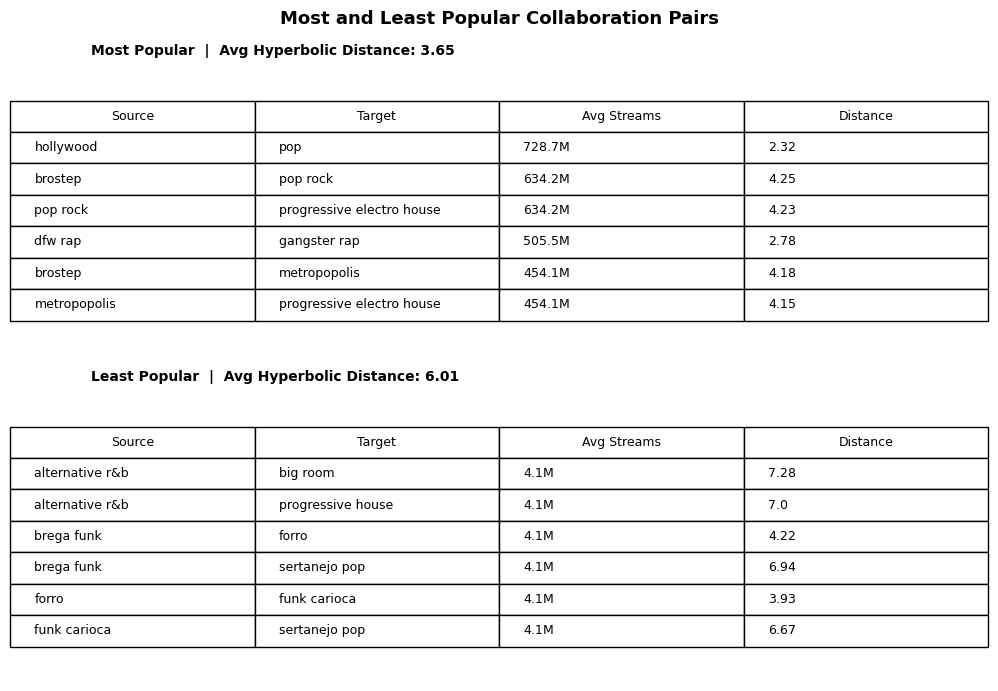

In [ ]:
top_popular = df.nlargest(6, "avg_streams")[["source", "target", "avg_streams", "hyperbolic_distance"]].copy()
least_popular = df.nsmallest(6, "avg_streams")[["source", "target", "avg_streams", "hyperbolic_distance"]].copy()

def format_streams(val):
    return f"{val/1e6:.1f}M"

top_popular["avg_streams"] = top_popular["avg_streams"].apply(format_streams)
least_popular["avg_streams"] = least_popular["avg_streams"].apply(format_streams)
top_popular["hyperbolic_distance"] = top_popular["hyperbolic_distance"].round(2)
least_popular["hyperbolic_distance"] = least_popular["hyperbolic_distance"].round(2)

avg_dist_popular = df.nlargest(6, "avg_streams")["hyperbolic_distance"].mean()
avg_dist_least = df.nsmallest(6, "avg_streams")["hyperbolic_distance"].mean()


fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.suptitle("Most and Least Popular Collaboration Pairs", 
             fontsize=13, fontweight="bold")

for ax, data, title, avg_dist in zip(
    axes,
    [top_popular, least_popular],
    ["Most Popular", "Least Popular"],
    [avg_dist_popular, avg_dist_least]
):
    ax.axis("off")
    ax.set_title(f"{title}  |  Avg Hyperbolic Distance: {avg_dist:.2f}",
                 fontsize=10, fontweight="bold", loc="left", pad=8)
    
    table = ax.table(
        cellText=data.values,
        colLabels=["Source", "Target", "Avg Streams", "Distance"],
        loc="center",
        cellLoc="left"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.6)

plt.tight_layout()
plt.show()

    diversity_group  n_pairs  avg_distance   avg_streams  median_streams
0     Low Diversity      859      1.593946  5.787240e+07      35631409.0
1  Medium Diversity      858      3.990371  5.684343e+07      38961459.0
2    High Diversity      859      6.353663  5.406212e+07      29329972.0


/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_11413/1482347949.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby("diversity_group").agg(
/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_11413/1482347949.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


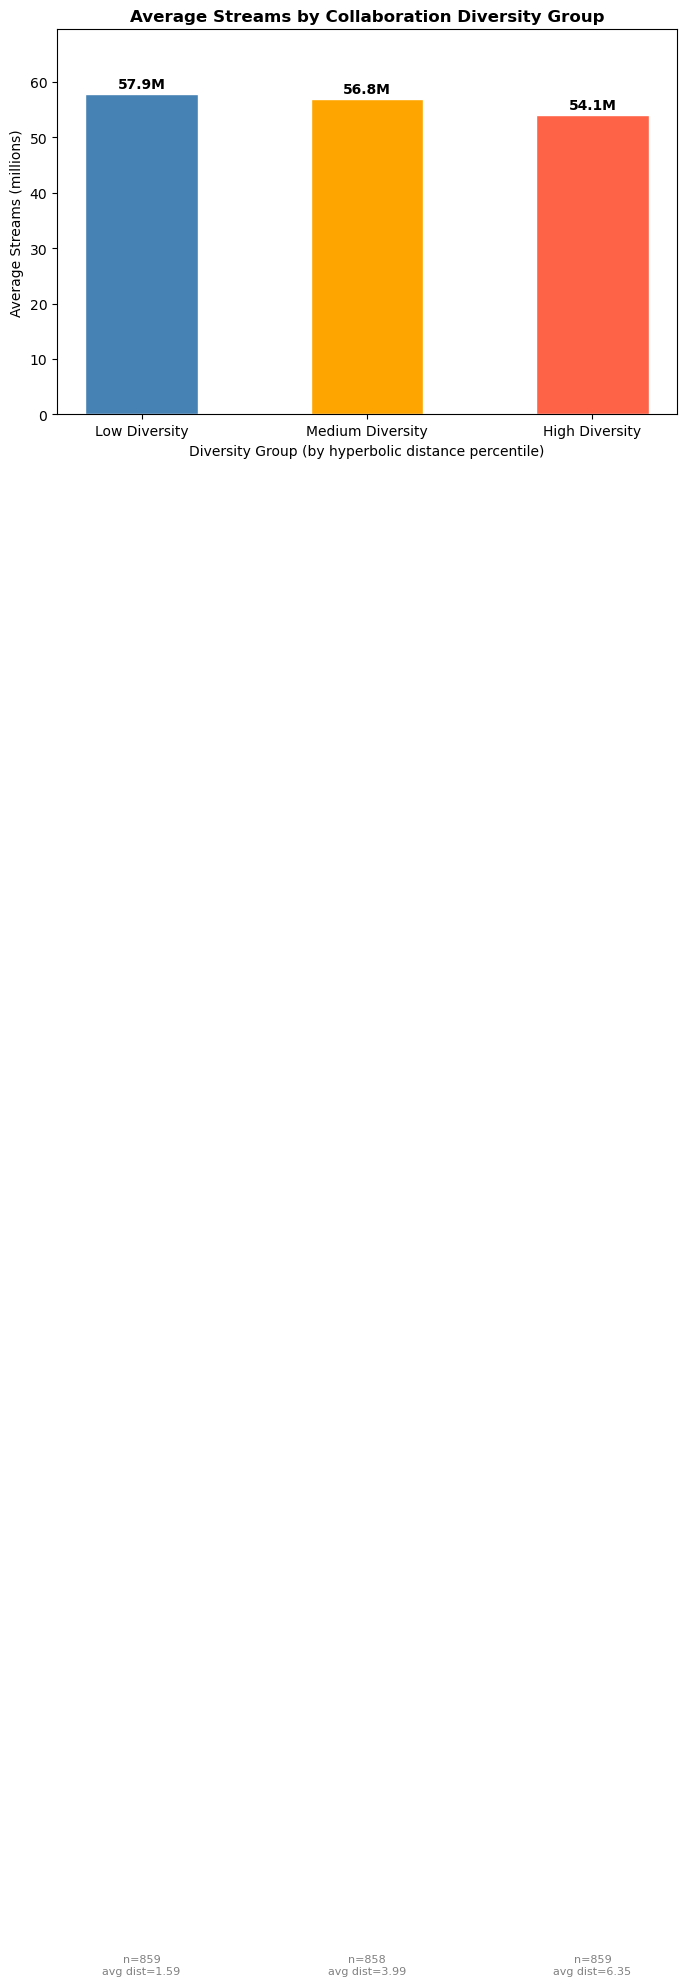

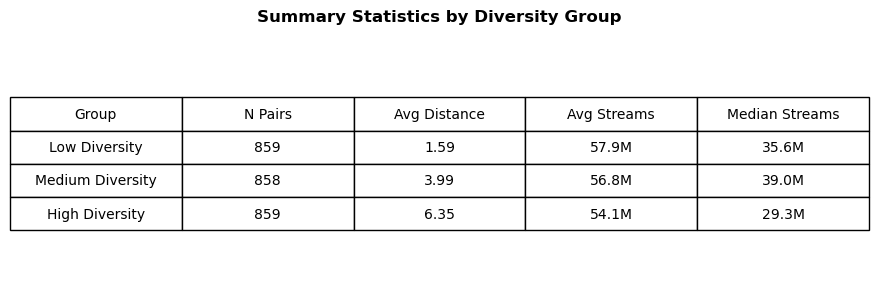

In [13]:
# ── Assign percentile groups based on hyperbolic distance ────────────────────
df["diversity_group"] = pd.qcut(
    df["hyperbolic_distance"],
    q=3,
    labels=["Low Diversity", "Medium Diversity", "High Diversity"]
)

# ── Compute stats per group ───────────────────────────────────────────────────
group_stats = df.groupby("diversity_group").agg(
    n_pairs=("hyperbolic_distance", "count"),
    avg_distance=("hyperbolic_distance", "mean"),
    avg_streams=("avg_streams", "mean"),
    median_streams=("avg_streams", "median")
).reset_index()

print(group_stats)

# ── Plot 1: Average streams per group (bar chart) ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue", "orange", "tomato"]
bars = ax.bar(group_stats["diversity_group"],
              group_stats["avg_streams"] / 1e6,
              color=colors, edgecolor="white", width=0.5)

# add value labels on top of bars
for bar, val in zip(bars, group_stats["avg_streams"] / 1e6):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}M",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

# add pair count below group name
for bar, n, avg_d in zip(bars, group_stats["n_pairs"], group_stats["avg_distance"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            -4,
            f"n={n}\navg dist={avg_d:.2f}",
            ha="center", va="top", fontsize=8, color="gray",
            transform=ax.get_xaxis_transform())

ax.set_title("Average Streams by Collaboration Diversity Group",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Diversity Group (by hyperbolic distance percentile)")
ax.set_ylabel("Average Streams (millions)")
ax.set_ylim(0, group_stats["avg_streams"].max() / 1e6 * 1.2)
plt.tight_layout()
plt.show()

# ── Plot 2: Summary table ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")

table_data = [
    [
        row["diversity_group"],
        f'{row["n_pairs"]}',
        f'{row["avg_distance"]:.2f}',
        f'{row["avg_streams"]/1e6:.1f}M',
        f'{row["median_streams"]/1e6:.1f}M'
    ]
    for _, row in group_stats.iterrows()
]

table = ax.table(
    cellText=table_data,
    colLabels=["Group", "N Pairs", "Avg Distance", "Avg Streams", "Median Streams"],
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.0)
ax.set_title("Summary Statistics by Diversity Group",
             fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [ ]:
groups = [group["avg_streams"].values for _, group in df.groupby("diversity_group")]
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis stat: {stat:.4f}, p-value: {p:.4f}")

Kruskal-Wallis stat: 4.0769, p-value: 0.1302


/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_11413/3668743763.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["avg_streams"].values for _, group in df.groupby("diversity_group")]
